In [4]:
import os
import numpy as np 
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score,accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns 
from collections import Counter

from fileinput import filename
import cv2
from PIL import Image
from pathlib import Path

import tensorflow as tf              # TensorFlow : framework Deep Learning
import tensorflow.keras as keras     # Keras : framework Deep Learning
from tensorflow.keras.applications import EfficientNetB0 
from tensorflow.keras.applications.efficientnet import preprocess_input # prétraitement spécifique à EfficientNet
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import layers # Keras : framework Deep Learning

from tqdm import tqdm
import joblib

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Configuration du dossier images
chemin = Path("../data/images/image_train")

# Chargement des labels pour avoir prdtypecode par image
data_train = pd.read_csv("../data/X_train_update.csv", nrows=15000)
data_labels = pd.read_csv("../data/Y_train_CVw08PX.csv", nrows=15000)

full_data = data_train.merge(data_labels, on=data_train.columns[0])

# Création de la colonne "image_filename" pour correspondre aux noms des fichiers d'images
full_data["image_filename"] = full_data.apply(
    lambda row: f"image_{row['imageid']}_product_{row['productid']}.jpg",
    axis=1
)

# Création de la colonne "image_path" pour stocker les chemins complets des images
full_data["image_path"] = full_data["image_filename"].apply(lambda f: chemin / f)

# Vérification de l'existence des fichiers d'images
full_data["image_exists"] = full_data["image_path"].apply(lambda p: p.exists())

# Suppression de la colonne "Unnamed:0" qui est un index inutile
full_data = full_data.drop(columns=["Unnamed: 0"])

# Affichage des statistiques sur les images
print(f"Images attendues : {len(full_data)}")
print(f"Images trouvées  : {full_data['image_exists'].sum()}")
print(f"Images manquantes: {(~full_data['image_exists']).sum()}")

Images attendues : 15000
Images trouvées  : 15000
Images manquantes: 0


In [6]:
display(full_data.head())

,designation,description,productid,imageid,prdtypecode,image_filename,image_path,image_exists
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,image_1263597046_product_3804725264.jpg,..\data\images\image_train\image_1263597046_pr...,True
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,image_1008141237_product_436067568.jpg,..\data\images\image_train\image_1008141237_pr...,True
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,image_938777978_product_201115110.jpg,..\data\images\image_train\image_938777978_pro...,True
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,image_457047496_product_50418756.jpg,..\data\images\image_train\image_457047496_pro...,True
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,image_1077757786_product_278535884.jpg,..\data\images\image_train\image_1077757786_pr...,True


In [7]:
#Lecture des meta-données d'une image

metadata = [] #création d'une liste pour stocker les meta-données des images

for _, col in full_data[full_data["image_exists"]].iterrows(): # Parcours des lignes du DataFrame pour les images existantes
    """ 
    Fonction de lecture des meta-données d'une image
    """
    image_path = col["image_path"] # Récupération du chemin de l'image à partir de la colonne "image_path"
    try:
        with Image.open(image_path) as img: # Ouverture de l'image pour lire ses meta-données
            w, h = img.size # Récupération de la largeur et de la hauteur de l'image
            metadata.append({ # Ajout des meta-données de l'image à la liste
                "imageid": col["imageid"],
                "productid": col["productid"],
                "prdtypecode": col["prdtypecode"], 
                "format": img.format, # Format de l'image (ex: JPEG, PNG)
                "mode": img.mode, # Mode de couleur (ex: RGB, RGBA, L)
                "width": w, # Largeur de l'image
                "height": h, # Hauteur de l'image
                "file_size": image_path.stat().st_size / 1024 # Taille du fichier en kilo-octets
            })
    except Exception as e:
        # En cas d'erreur lors de la lecture de l'image, on ajoute une entrée avec des valeurs nulles et un message d'erreur
        metadata.append({
            "imageid": col["imageid"],
            "productid": col["productid"],
            "prdtypecode": col["prdtypecode"],
            "width": None, "height": None,
            "mode": "ERROR",
            "file_size": None
        })
        print(f"Erreur lors de la lecture de {image_path}: {e}")

# Création d'un DataFrame à partir de la liste de meta-données
df_metadata = pd.DataFrame(metadata)

# Images illisibles
n_errors = (df_metadata["mode"] == "ERROR").sum() 
print(f"Nombre d'images illisibles : {n_errors}")

# Affichage des statistiques descriptives des images
print("\n___________________________________\n")
print("Statistiques descriptives des images\n")
print("\n___________________________________\n")
print("Format de l'image :", df_metadata[["format"]].describe())
print("\nModes de couleur :", df_metadata[["mode"]].describe())
print("\nLargeur de l'image en px:", df_metadata[["width"]].describe())
print("\nHauteur de l'image en px:", df_metadata[["height"]].describe())
print("\nTailles de fichier en ko:", df_metadata[["file_size"]].describe().round(1))

Nombre d'images illisibles : 0

___________________________________

Statistiques descriptives des images


___________________________________

Format de l'image :        format
count   15000
unique      1
top      JPEG
freq    15000

Modes de couleur :          mode
count   15000
unique      1
top       RGB
freq    15000

Largeur de l'image en px:          width
count  15000.0
mean     500.0
std        0.0
min      500.0
25%      500.0
50%      500.0
75%      500.0
max      500.0

Hauteur de l'image en px:         height
count  15000.0
mean     500.0
std        0.0
min      500.0
25%      500.0
50%      500.0
75%      500.0
max      500.0

Tailles de fichier en ko:        file_size
count    15000.0
mean        26.0
std         13.4
min          2.6
25%         15.5
50%         24.1
75%         34.9
max        104.1


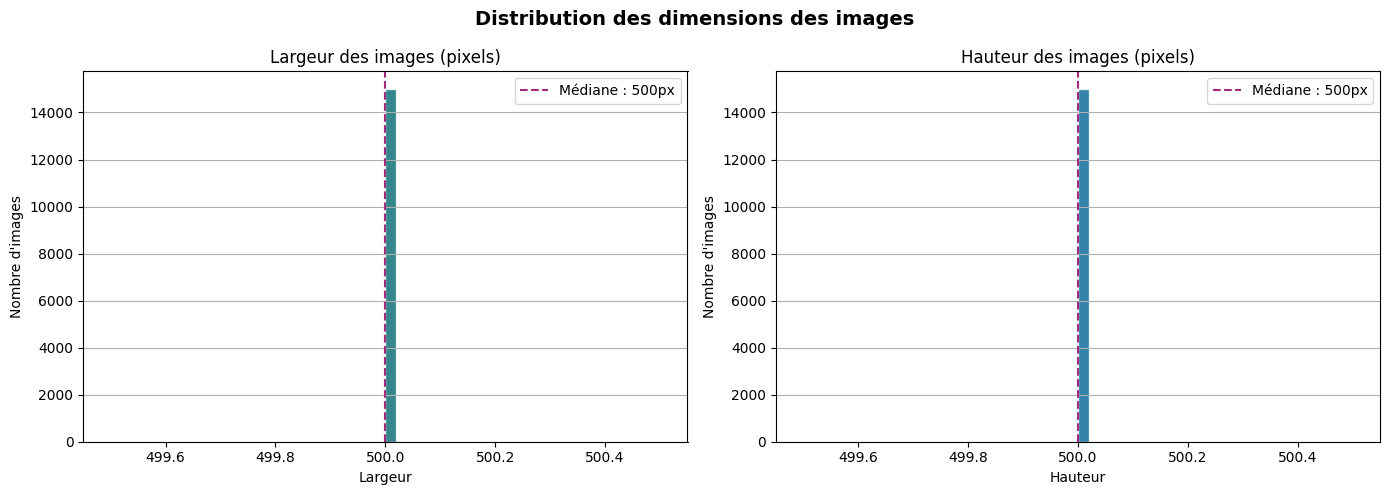

In [8]:
# Visualisation de la distribution des dimensions des images
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des dimensions des images", fontsize=14, fontweight="bold")

# Histogramme de la largeur
axes[0].hist(df_metadata["width"].dropna(), bins=50, color="#01696f", alpha=0.8, edgecolor="white")
axes[0].axvline(df_metadata["width"].median(), color="#a12c7b", linestyle="--", label=f"Médiane : {df_metadata['width'].median():.0f}px")
axes[0].set_title("Largeur des images (pixels)")
axes[0].set_xlabel("Largeur")
axes[0].set_ylabel("Nombre d'images")
axes[0].legend()
axes[0].grid(axis="y")

# Histogramme de la hauteur
axes[1].hist(df_metadata["height"].dropna(), bins=50, color="#006494", alpha=0.8, edgecolor="white")
axes[1].axvline(df_metadata["height"].median(), color="#a12c7b", linestyle="--", label=f"Médiane : {df_metadata['height'].median():.0f}px")
axes[1].set_title("Hauteur des images (pixels)")
axes[1].set_xlabel("Hauteur")
axes[1].set_ylabel("Nombre d'images")
axes[1].legend()
axes[1].grid(axis="y")

plt.tight_layout()
plt.savefig("../reports/figures/viz_image_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()


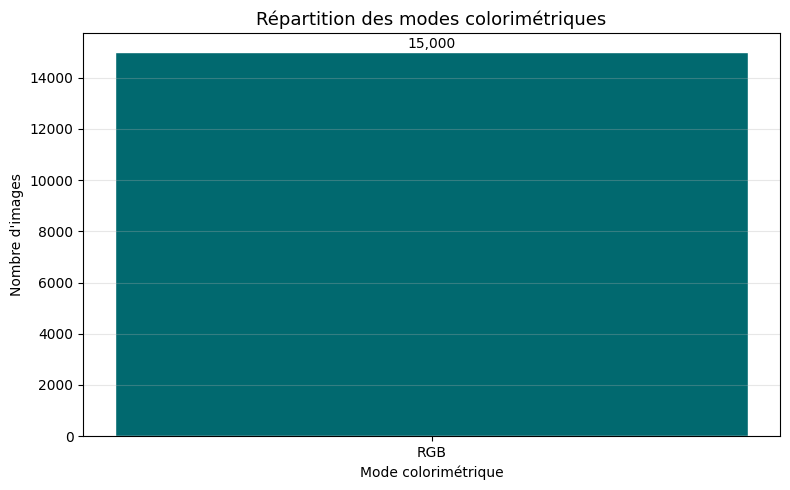

In [9]:
# Visualisation de la distribution des modes de couleur
mode_counts = df_metadata["mode"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(mode_counts.index, mode_counts.values, color="#01696f", edgecolor="white")

# Affichage des valeurs au-dessus de chaque barre
for bar, val in zip(bars, mode_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{val:,}",
        ha="center", va="bottom", fontsize=10
    )

plt.title("Répartition des modes colorimétriques", fontsize=13)
plt.xlabel("Mode colorimétrique")
plt.ylabel("Nombre d'images")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/viz_image_modes.png", dpi=150, bbox_inches="tight")
plt.show()

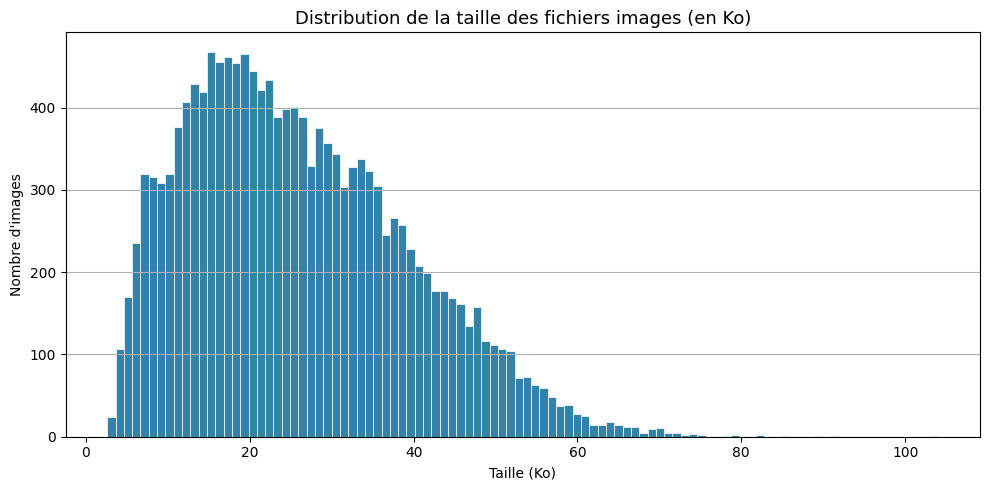

In [10]:
# Visualisation de la distribution des tailles de fichier

plt.figure(figsize=(10, 5))

sns.histplot(df_metadata["file_size"].dropna(), bins=100, color="#006494", edgecolor="white", alpha=0.8) # Histogramme de la taille des fichiers en Ko 

plt.title("Distribution de la taille des fichiers images (en Ko)", fontsize=13)
plt.ylabel("Nombre d'images")
plt.xlabel("Taille (Ko)")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("../reports/figures/viz_image_filesize.png", dpi=150, bbox_inches="tight")
plt.show()

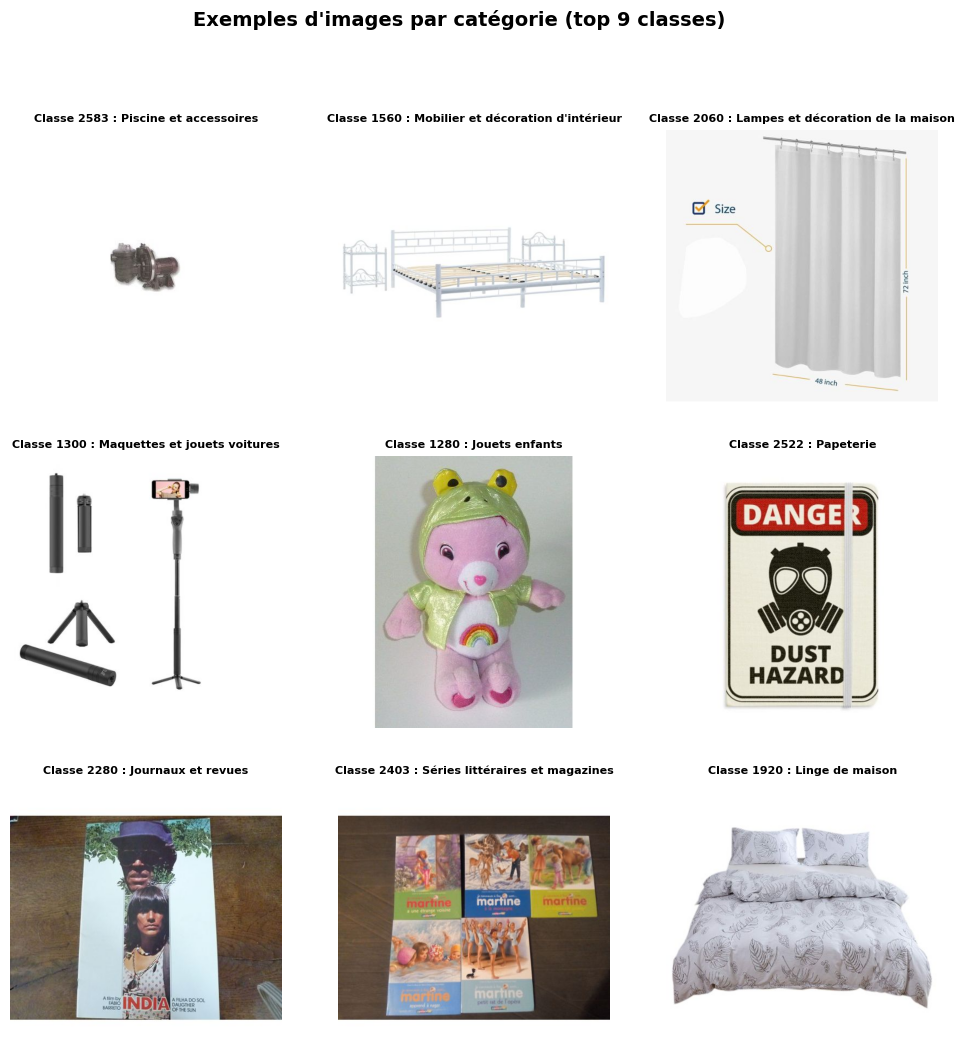

In [43]:
# Top 9 classes par nombre d'images dans le dataset
top_classes = df_metadata["prdtypecode"].value_counts().head(9).index.tolist()

df_dictionnaire = pd.read_csv("../data/dictionnaire.csv")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Exemples d'images par catégorie (top 9 classes)", fontsize=14, fontweight="bold")

for ax, code in zip(axes.flatten(), top_classes):
    # On prend une image aléatoire de cette classe
    sample_row = df_metadata[df_metadata["prdtypecode"] == code].sample(1, random_state=42).iloc[0]
    img_path = chemin / f"image_{int(sample_row['imageid'])}_product_{int(sample_row['productid'])}.jpg"
    
    try:
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        # Récupération du nom de la classe à partir de la correspondance du prdtypecode dans ../data/dictionnaire.csv
        class_name = df_dictionnaire[df_dictionnaire["prdtypecode"] == code]["categorie"].iloc[0]
        ax.set_title(f"Classe {code} : {class_name}" , fontsize=8, fontweight="bold")
    except Exception:
        ax.text("Image\nnon disponible", ha="center", va="center", transform=ax.transAxes)
    
    ax.axis("off")  # on masque les axes (x, y) pour un rendu propre

plt.savefig("../reports/figures/viz_image_grid.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Encodage des labels de la colonne "prdtypecode" en valeurs numériques pour l'entraînement du modèle
le = LabelEncoder()
full_data["label"] = le.fit_transform(full_data["prdtypecode"])

N_CLASSES = len(le.classes_) # Nombre de classes uniques dans la colonne "prdtypecode"
print("Nombre de classes :", N_CLASSES)

# On ne garde que les images existantes pour l'entraînement et le test
data_util = full_data[full_data["image_exists"]].copy().reset_index(drop=True)

# Création des ensembles d'entraînement et de test
df_train, df_test = train_test_split(
    data_util, test_size=0.2, random_state=42, stratify=data_util["label"]
)

# Affichage du nombre d'images dans les ensembles d'entraînement et de test
print(f"Train : {len(df_train)} images")
print(f"Test  : {len(df_test)} images")


Nombre de classes : 27
Train : 12000 images
Test  : 3000 images


In [13]:
# Fonction de chargement d'une image à partir de son chemin, redimensionnement et normalisation

def load_image_cv2(image_id, product_id, img_dir, target_size=(224, 224)): #
    """
    Fonction de chargement d'une image à partir de son chemin, redimensionnement et normalisation pour l'entraînement d'un modèle de classification d'images.
    args:
        image_id (int): ID de l'image à charger
        product_id (int): ID du produit associé à l'image
        img_dir (str): Répertoire contenant les images
        target_size (tuple): Taille cible pour le redimensionnement de l'image (par défaut : (224, 224))
    """
    filename = f"image_{image_id}_product_{product_id}.jpg" # Construction du nom de fichier de l'image
    img_path = Path(img_dir) / filename # Construction du chemin complet de l'image à partir du répertoire et du nom de fichier
    
    if not img_path.exists():
        # Si image manquante → créer image noire
        img = np.zeros((target_size[1], target_size[0], 3), dtype=np.uint8)
        return img
    
    # Lecture de l'image à partir du chemin avec openCV
    img = cv2.imread(str(img_path))

    if img is None:
        # Si image illisible → créer image noire
        img = np.zeros((target_size[1], target_size[0], 3), dtype=np.uint8)
        return img
    
    # Redimensionnement de l'image à la taille cible
    img = cv2.resize(img, target_size)

    # Conversion de l'image de BGR à RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalisation des pixels de l'image pour la compréhension du modèle EfficientNetB0 (0, 255)
    return img.astype(np.float32)

In [14]:
#  Chargement du dataset image
X = []
y = []

def load_images_dataset(df, img_dir, target_size=(224, 224)):
    """
    Fonction de chargement du dataset d'images à partir d'un DataFrame contenant les informations sur les images et d'un répertoire d'images.
    args:
        df (DataFrame): DataFrame contenant les informations sur les images (image_id, product_id, label)
        img_dir (str): Répertoire contenant les images
        target_size (tuple): Taille cible pour le redimensionnement des images (par défaut : (224, 224))
        Retourne X (images) et y (label = prdtypecode encodé)
    """
    print("Chargement des images...")
    for _, row in tqdm(df.iterrows(), total=len(df)): #tqdm pour afficher une barre de progression lors du chargement des images
        img = load_image_cv2( # Chargement de l'image avec la fonction load_image_cv2
            image_id = int(row["imageid"]), # Récupération de l'ID de l'image
            product_id = int(row["productid"]), # Récupération de l'ID du produit associé à l'image
            img_dir = img_dir, # Répertoire contenant les images
            target_size = target_size # Taille cible pour le redimensionnement de l'image
        )
        
        X.append(img) # Ajout de l'image chargée à la liste X
        y.append(row["label"]) # Ajout du label associé à l'image à la liste y
    
    return np.array(X), np.array(y) # Retourne les listes X et y converties en tableaux numpy

In [15]:
# Chargement en mémoire
print("Chargement du dataset d'entraînement...")
X_train, y_train = load_images_dataset(df_train, chemin, target_size=(224, 224))

print("Chargement du dataset de test...")
X_test, y_test = load_images_dataset(df_test, chemin, target_size=(224, 224))

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Chargement du dataset d'entraînement...
Chargement des images...


100%|██████████| 12000/12000 [00:22<00:00, 523.73it/s]


Chargement du dataset de test...
Chargement des images...


100%|██████████| 3000/3000 [00:09<00:00, 305.48it/s]


X_train shape: (12000, 224, 224, 3), y_train shape: (12000,)


In [16]:
# Moyenne des pixels noirs et blancs
mean_black_pixel_value = X_train.mean()
print(f"Moyenne des pixels noirs (train) : {mean_black_pixel_value:.2f}")

mean_white_pixel_value = X_train.mean()
print(f"Moyenne des pixels blancs (train) : {mean_white_pixel_value:.2f}")

Moyenne des pixels noirs (train) : 195.06
Moyenne des pixels blancs (train) : 195.06


In [17]:
# Création du modèle de classification d'images en utilisant EfficientNetB0 pré-entraîné sur ImageNet

base_ENB_model = EfficientNetB0( #
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
    )

base_ENB_model.trainable = False # On gèle les poids du modèle pré-entraîné pour ne pas les mettre à jour lors de l'entraînement du modèle de classification d'images

ENB_model = keras.Sequential([
    base_ENB_model, # Modèle pré-entraîné EfficientNetB0 comme base du modèle de classification d'images
    layers.GlobalAveragePooling2D(), # Couche de pooling global pour réduire les dimensions de sortie du modèle pré-entraîné
    layers.Dropout(0.5), # Couche de dropout pour éviter le surapprentissage
    layers.Dense(N_CLASSES, activation="softmax") # Couche de sortie avec activation softmax pour la classification multi-classes
])

ENB_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), # Optimiseur Adam avec un taux d'apprentissage de 0.001
    loss="sparse_categorical_crossentropy", # Fonction de perte pour la classification multi-classes avec des labels encodés en entiers
    metrics=["accuracy"] # Métrique d'évaluation de la précision du modèle
)

ENB_model.summary() # Affichage de la structure du modèle de classification d'images basé sur EfficientNetB0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │        34,587 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,084,158 (15.58 MB)

 Trainable params: 34,587 (135.11 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [18]:
# Définition des callbacks pour l'entraînement du modèle de classification d'images
# Callbacks : fonctions qui sont appelées à différents moments de l'entraînement du modèle pour effectuer des actions spécifiques (ex: arrêt précoce, réduction du taux d'apprentissage)
# EarlyStopping : arrête l'entraînement si la performance du modèle sur les données de validation ne s'améliore pas pendant un certain nombre d'époques (patience)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
        ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        verbose=1,
        )
]

In [19]:
# Entrainement du modèle de classification d'images basé sur EfficientNetB0 avec normalisation spécifique à EfficientNet et callbacks pour l'arrêt précoce et la réduction du taux d'apprentissage

history = ENB_model.fit(
    preprocess_input(X_train), # Normalisation des images d'entraînement avec la fonction de prétraitement spécifique à EfficientNet
    y_train, # Labels d'entraînement
    validation_data=(preprocess_input(X_test), y_test), # Normalisation des images de test et labels de test pour l'évaluation du modèle à chaque époque
    validation_split=0.2, # Fraction des données d'entraînement à utiliser pour la validation
    epochs=20, # Nombre maximum d'époques pour l'entraînement du modèle
    batch_size=32, # Taille des lots d'entraînement
    callbacks=callbacks # Callbacks définis précédemment pour l'arrêt précoce et la réduction du taux d'apprentissage
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 154s 388ms/step - accuracy: 0.3811 - loss: 2.1780 - val_accuracy: 0.5201 - val_loss: 1.6422 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 119s 319ms/step - accuracy: 0.5007 - loss: 1.7159 - val_accuracy: 0.5619 - val_loss: 1.4762 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 117s 314ms/step - accuracy: 0.5217 - loss: 1.6097 - val_accuracy: 0.5841 - val_loss: 1.3871 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 117s 313ms/step - accuracy: 0.5357 - loss: 1.5446 - val_accuracy: 0.6049 - val_loss: 1.3257 - learning_rate: 0.0010
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 118s 316ms/step - accuracy: 0.5533 - loss: 1.4900 - val_accuracy: 0.6165 - val_loss: 1.2796 - learning_rate: 0.0010
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 118s 316ms/step - accuracy: 0.5556 - loss: 1.4606 - val_accuracy: 0.6215 - val_loss: 1.2521 - learning_rate: 0.0010
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 118s 314ms/step - accura

In [20]:
# Prédictions sur set de test
y_pred_proba = ENB_model.predict(preprocess_input(X_test))
y_pred = np.argmax(y_pred_proba, axis=1) # Conversion des probabilités prédites en classes prédictes en prenant l'indice de la classe avec la probabilité maximale pour chaque échantillon de test

# Métriques d'évaluation du modèle de classification d'images
acc = accuracy_score(y_test, y_pred) # Calcul de la précision du modèle en comparant les labels de test avec les classes prédictes
f1_macro = f1_score(y_test, y_pred, average="macro") # Calcul du F1-score macro pour évaluer la performance du modèle en prenant en compte les classes déséquilibrées
f1_weighted = f1_score(y_test, y_pred, average="weighted") # Calcul du F1-score pondéré pour évaluer la performance du modèle en prenant en compte les classes déséquilibrées et le nombre d'échantillons par classe

print("\n___________________________________\n")
print("Résultats du modèle de classification d'images EfficientNetB0 :")
print("\n___________________________________\n")
print("\nPrécision :", acc)
print("F1-score macro :", f1_macro)
print("F1-score pondéré :",f1_weighted)

469/469 ━━━━━━━━━━━━━━━━━━━━ 92s 189ms/step

___________________________________

Résultats du modèle de classification d'images EfficientNetB0 :

___________________________________


Précision : 0.6725333333333333
F1-score macro : 0.6595271178351282
F1-score pondéré : 0.6673293312134441


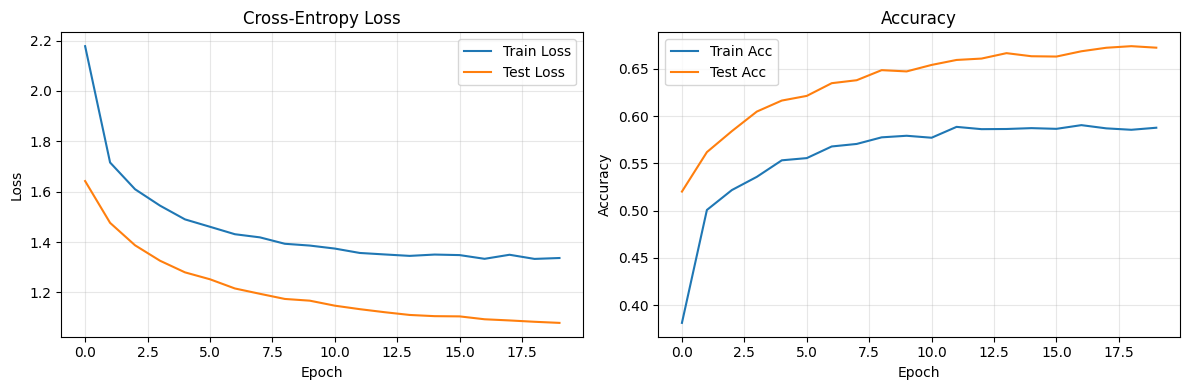

In [21]:
# Visualisation des courbes d'apprentissage du modèle 

plt.figure(figsize=(12, 4))

# Courbe de la cross-entropie
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.title("Cross-Entropy Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

# Courbe de l'accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Test Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)


plt.tight_layout()
plt.savefig("../reports/figures/viz_img_ENB_courbes.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 1400x1200 with 0 Axes>

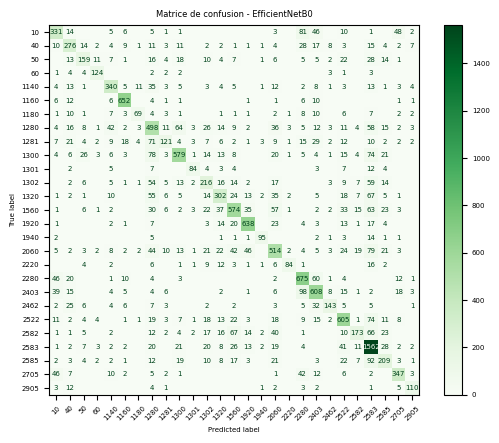

In [30]:
# Matrice de confusion

cm_ENB = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14,12))
disp_ENB = ConfusionMatrixDisplay(confusion_matrix=cm_ENB, display_labels=le.classes_.astype(str))
disp_ENB.plot(cmap="Greens", values_format="d", xticks_rotation=45)

for text in disp_ENB.text_.flatten():
    if text.get_text() == "0":
        text.set_text("") # Supprime les annotations "0" pour une meilleure lisibilité

plt.title("Matrice de confusion - EfficientNetB0")
plt.savefig("../reports/figures/viz_img_ENB_confusion.png", dpi=150, bbox_inches="tight")
plt.rcParams['font.size'] = 5
plt.show()

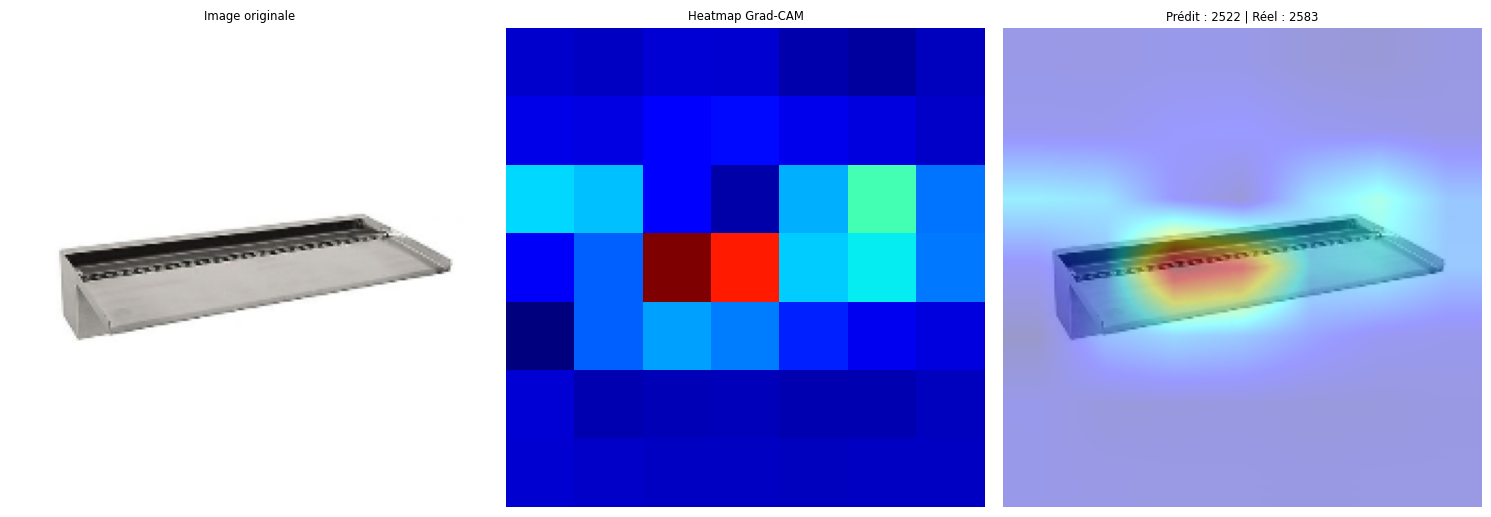

In [25]:
# Récupérer les couches du modèle Sequential
# On récupère les différentes couches du modèle de classification d'images basé sur EfficientNetB0 pour pouvoir les utiliser dans la fonction de Grad-CAM 
# sans avoir à créer un modèle intermédiaire pour accéder aux sorties de la base convolutionnelle et de la tête de classification
backbone = ENB_model.layers[0]   # EfficientNetB0 
gap_layer = ENB_model.layers[1]  # GlobalAveragePooling2D 
drop_layer = ENB_model.layers[2] # Dropout 
pred_layer = ENB_model.layers[3] # Dense softmax 

# Fonction Grad-CAM sans grad_model intermédiaire
def make_gradcam_heatmap(img_array, pred_index=None):
    with tf.GradientTape() as tape:
        # sortie de la base conv
        conv_outputs = backbone(img_array, training=False)
        tape.watch(conv_outputs)

        # tête de classification
        x = gap_layer(conv_outputs)
        x = drop_layer(x, training=False)
        preds = pred_layer(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()

# Superposition heatmap / image
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img.astype(np.uint8), 1 - alpha, heatmap, alpha, 0)
    return superimposed

# Exemple sur une image test
idx = 45
img = X_test[idx]
img_input = np.expand_dims(img.copy(), axis=0)
img_input = preprocess_input(img_input)

heatmap, preds = make_gradcam_heatmap(img_input)

pred_class_idx = np.argmax(preds[0])
pred_class_label = le.inverse_transform([pred_class_idx])[0]

true_class_idx = y_test[idx]
true_class_label = le.inverse_transform([true_class_idx])[0]

gradcam_img = overlay_gradcam(img, heatmap)

# Affichage 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img.astype("uint8"))
axes[0].set_title("Image originale")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Heatmap Grad-CAM")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(gradcam_img, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Prédit : {pred_class_label} | Réel : {true_class_label}")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("../reports/figures/gradcam_ENB_interpretation.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
ENB_model.save("../models/ENB_model.keras")